### 1. Getting Setup

In [1]:
import torch 
import torchvision
print(f"Torch version: {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Torch version: 2.11.0+cu128
TorchVision version: 0.26.0+cu128


In [2]:
import torch 
import torchvision
from torchvision import transforms
from torch import nn 
import matplotlib.pyplot as plt 

# try to import summary from torchinfo else if not found it will download and import 
try: 
    from torchinfo import summary
except:
    print(f"[INFO] Couldn't find summary...Downloading....")
    !pip install -q torchinfo
    from torchinfo import summary
    
""" try to import data_setup, engine from going_modular.going_modular 
else if not found it will clone github repository, then move pytorch/going_modular(all files)
into current working directory then it will remove pytorch file and import data_setup, engine
"""
try: 
    from going_modular.going_modular import data_setup, engine
except: 
    print(f"[INFO] Couldn't find going_modular...Downloading...")
    !git clone https://github.com/Abisheklimbu/pytorch
    !mv pytorch/going_modular . 
    !rm -rf pytorch 
    from going_modular.going_modular import data_setup, engine

[INFO] Couldn't find summary...Downloading....
[INFO] Couldn't find going_modular...Downloading...
Cloning into 'pytorch'...
remote: Enumerating objects: 2705, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2705 (delta 3), reused 3 (delta 0), pack-reused 2691 (from 2)
Receiving objects: 100% (2705/2705), 317.65 MiB | 42.60 MiB/s, done.
Resolving deltas: 100% (262/262), done.
Updating files: 100% (3439/3439), done.


In [3]:
# device agnostic code 
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
# set up seeds 
def set_seed(seed:int = 42):
    # set manual_seed 
    torch.manual_seed(seed)
    
    # set cuda manual_seed
    torch.cuda.manual_seed(seed)

set_seed

<function __main__.set_seed(seed: int = 42)>

### 2. Get Data

In [5]:
from pathlib import Path 
import requests
import zipfile
import os 

def download_data(source: str, 
                  destination: str,
                  remove_source: bool = True) -> Path:
    """Downloads a zipped dataset from source and unzips to destination.

    Args:
        source (str): A link to a zipped file containing data.
        destination (str): A target directory to unzip data to.
        remove_source (bool): Whether to remove the source after downloading and extracting.
    
    Returns:
        pathlib.Path to downloaded data.
    
    Example usage:
        download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                      destination="pizza_steak_sushi")
    """
    # Setup path to data folder
    data_path = Path("data/")
    image_path = data_path / destination

    # If the image folder doesn't exist, download it and prepare it... 
    if image_path.is_dir():
        print(f"[INFO] {image_path} directory exists, skipping download.")
    else:
        print(f"[INFO] Did not find {image_path} directory, creating one...")
        image_path.mkdir(parents=True, exist_ok=True)
        
        # Download pizza, steak, sushi data
        target_file = Path(source).name
        with open(data_path / target_file, "wb") as f:
            request = requests.get(source)
            print(f"[INFO] Downloading {target_file} from {source}...")
            f.write(request.content)

        # Unzip pizza, steak, sushi data
        with zipfile.ZipFile(data_path / target_file, "r") as zip_ref:
            print(f"[INFO] Unzipping {target_file} data...") 
            zip_ref.extractall(image_path)

        # Remove .zip file
        if remove_source:
            os.remove(data_path / target_file)
    
    return image_path

In [6]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


PosixPath('data/pizza_steak_sushi')

In [7]:
train_dir = image_path/"train"
test_dir = image_path/"test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 3. Get Dataset and DataLoader

In [8]:
# Create image size (from Table 3 in the ViT paper)
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [9]:
from going_modular.going_modular import data_setup, engine

In [10]:
# Set the batch size
BATCH_SIZE = 32 

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7a918955df10>,
 ['pizza', 'steak', 'sushi'])

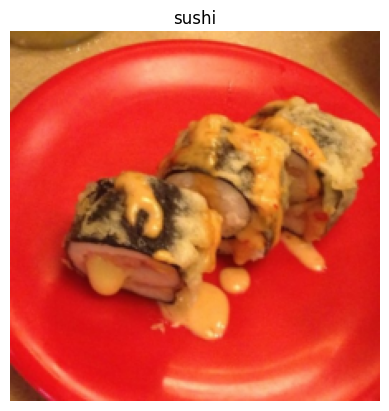

In [11]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

### 4. Replicating ViT Paper 

In [13]:
# Create example values
height = 224 
width = 224 
color_channels = 3 
patch_size = 16 

# Calculate N (number of patches)
number_of_patches = int((height * width) / patch_size**2)
print(f"Number of patches (N) with image height (H={height}), width (W={width}) and patch size (P={patch_size}): {number_of_patches}")

Number of patches (N) with image height (H=224), width (W=224) and patch size (P=16): 196


In [14]:
# Input shape (this is the size of a single image)
embedding_layer_input_shape = (height, width, color_channels)

# Output shape
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(f"Input shape (single 2D image): {embedding_layer_input_shape}")
print(f"Output shape (single 2D image flattened into patches): {embedding_layer_output_shape}")

Input shape (single 2D image): (224, 224, 3)
Output shape (single 2D image flattened into patches): (196, 768)


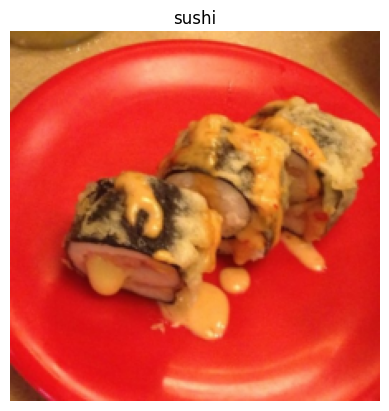

In [22]:
# Turning single image into patches 
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis("off");

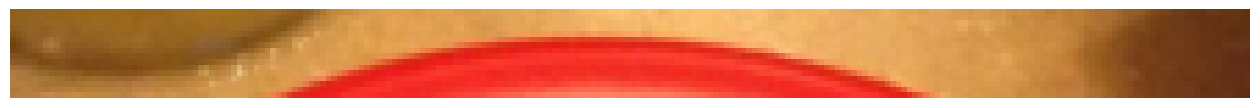

In [25]:
image_permuted = image.permute(1,2,0)
patch_size = 16 
plt.figure(figsize=(patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :])
plt.axis(False);


Number of patches per row: 14.0
Patch size: 16 pixels x 16 pixels


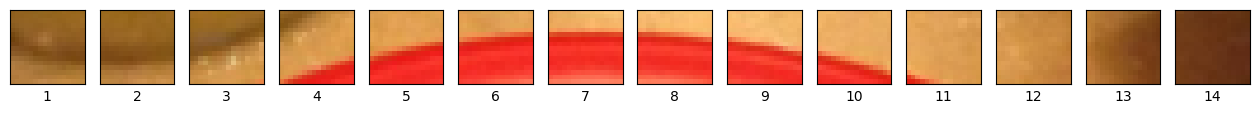

In [ ]:
# Patches for top row of image 
img_size = 224
patch_size = 16
num_patches = img_size / patch_size
assert img_size % patch_size == 0

print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

fig, ax = plt.subplots(nrows=1, 
                       ncols=img_size//patch_size, 
                       figsize=(patch_size, patch_size), 
                       sharex=True, 
                       sharey=True)

for i,patch in enumerate(range(0, img_size, patch_size)):
    ax[i].imshow(image_permuted[:patch_size, patch:patch + patch_size, :])
    ax[i].set_xlabel(i+1)
    ax[i].set_xticks([])
    ax[i].set_yticks([])

Number of patches per row: 14.0
Total patches: 196.0
Patch size: 16 pixels x 16 pixels


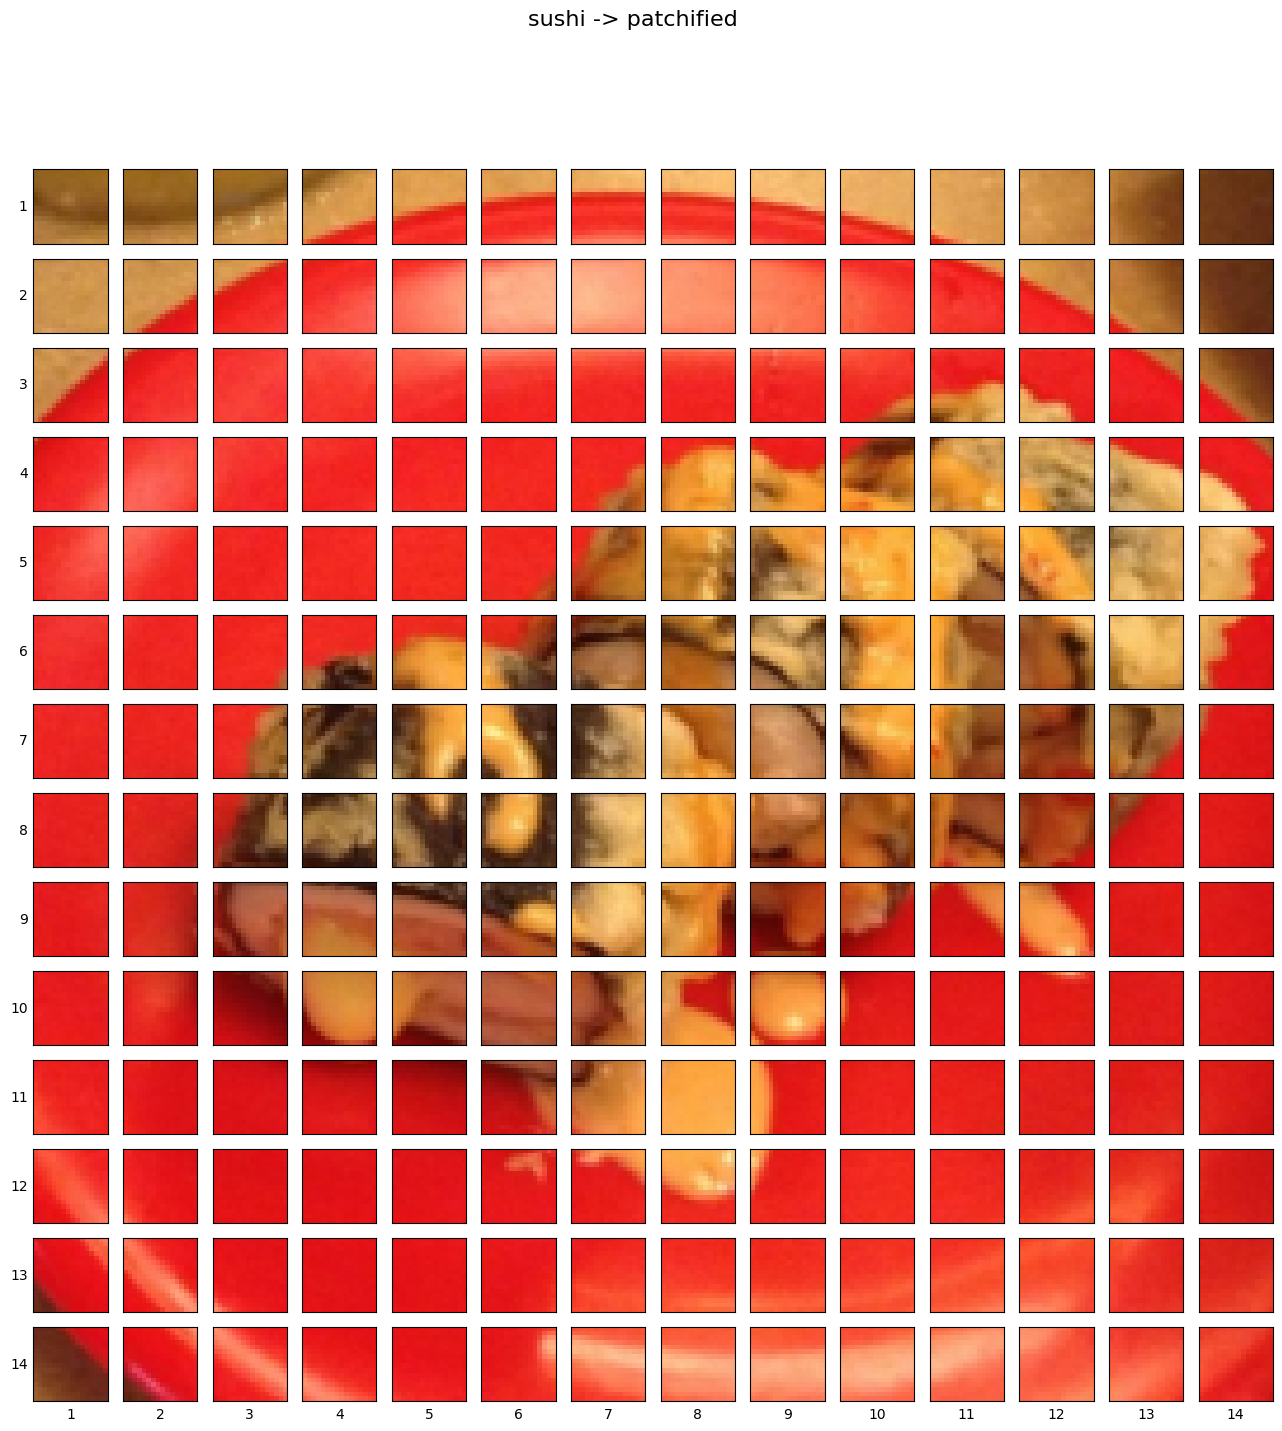

In [32]:
# Patches for whole image 
img_size = 224
patch_size = 16
num_patches = img_size / patch_size
assert img_size % patch_size == 0

print(f"Number of patches per row: {num_patches}\nTotal patches: {num_patches*num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

fig, ax = plt.subplots(nrows=img_size//patch_size,  
                       ncols=img_size//patch_size, 
                       figsize=(patch_size, patch_size), 
                       sharex=True, 
                       sharey=True)

for i,patch_height in enumerate(range(0, img_size, patch_size)):
    for j,patch_width in enumerate(range(0, img_size, patch_size)):
        ax[i,j].imshow(image_permuted[patch_height:patch_height+patch_size, patch_width:patch_width+patch_size, :])
        ax[i,j].set_ylabel(i+1, rotation="horizontal", horizontalalignment="right", verticalalignment="center")
        ax[i,j].set_xlabel(j+1)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])
        ax[i,j].label_outer()
        
fig.suptitle(f"{class_names[label]} -> patchified", fontsize=16)
plt.show()
    

#### CREATING IMAGE PATCHES WITH torch.nn.Conv2d()

In [34]:
from torch import nn
patch_size = 16 
conv2d = nn.Conv2d(
    in_channels=3, 
    out_channels=768, 
    kernel_size=patch_size, 
    stride=patch_size, 
    padding=0
)

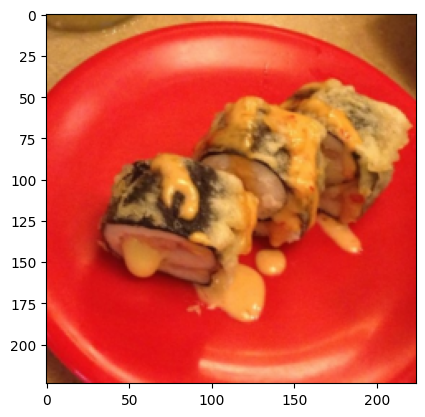

In [ ]:
plt.imshow(image_permuted)

In [36]:
img_out_of_conv2d = conv2d(image.unsqueeze(0))
print(img_out_of_conv2d.shape)

torch.Size([1, 768, 14, 14])


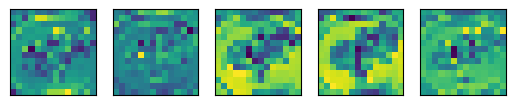

In [38]:
# plotting random 5 convolutional feature maps 
import random 
random_idx = random.sample(range(0,768), k=5)
fig, ax = plt.subplots(nrows=1, 
                       ncols=5)

for i, idx in enumerate(random_idx):
    img_conv_feature_map = img_out_of_conv2d[:, idx, :, :]
    ax[i].imshow(img_conv_feature_map.squeeze().detach().numpy())
    ax[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

In [41]:
# Get single feature map in tensor form 
single_feature_map = img_out_of_conv2d[:,0,:,:]
single_feature_map, single_feature_map.requires_grad

(tensor([[[0.3290, 0.3317, 0.4481, 0.5314, 0.4629, 0.4741, 0.4779, 0.5057,
           0.4789, 0.5049, 0.5616, 0.4917, 0.3163, 0.2293],
          [0.5376, 0.5371, 0.4516, 0.4942, 0.5808, 0.6894, 0.6900, 0.6352,
           0.5625, 0.4986, 0.5137, 0.4252, 0.3338, 0.2245],
          [0.4708, 0.4240, 0.4945, 0.4847, 0.4824, 0.4659, 0.4671, 0.4584,
           0.4572, 0.4171, 0.4627, 0.5152, 0.4081, 0.2589],
          [0.4155, 0.5508, 0.4639, 0.4374, 0.4299, 0.4315, 0.4133, 0.5203,
           0.4292, 0.3612, 0.4411, 0.5105, 0.5378, 0.5049],
          [0.4901, 0.4651, 0.4292, 0.4336, 0.4248, 0.4163, 0.3636, 0.4751,
           0.5210, 0.5674, 0.4259, 0.3983, 0.5641, 0.6190],
          [0.4552, 0.4194, 0.4133, 0.3550, 0.4832, 0.3580, 0.3149, 0.3696,
           0.4583, 0.5598, 0.4068, 0.3110, 0.5533, 0.4105],
          [0.4216, 0.4233, 0.3778, 0.1374, 0.5241, 0.2865, 0.4621, 0.4759,
           0.4743, 0.4639, 0.3251, 0.2848, 0.4092, 0.3633],
          [0.3975, 0.3702, 0.2925, 0.3593, 0.3494, 0.28

In [42]:
single_feature_map.shape

torch.Size([1, 14, 14])

#### FLATTENING THE PATCH EMBEDDINGS WITH torch.nn.Flatten()